In [1]:
import sys
sys.path.append(r'C:\projects\soil_acid_risk\src')
from preprocessing import load_raster
import numpy as np

data, transform, pixel_area = load_raster(r'C:\projects\soil_acid_risk\data\landuse_2023.tif')
print("数据形状:", data.shape)
print("像元面积（平方米）:", pixel_area)

数据形状: (4045, 4845)
像元面积（平方米）: 1000000.0


In [1]:
import sys
sys.path.append(r'C:\projects\soil_acid_risk\src')
from preprocessing import load_raster,classify_ph
import numpy as np
ph_data, _, _ = load_raster(r'C:\projects\soil_acid_risk\data\pH_0-5cm_1km.tif')
ph_data = ph_data/100
ph_class = classify_ph(ph_data)

print("pH数据形状:", ph_data.shape)
print("pH值范围: {:.2f} - {:.2f}".format(np.nanmin(ph_data), np.nanmax(ph_data)))
for i in range(1, 6):
    print(f"  等级 {i}: {np.sum(ph_class == i)} 个像元")

pH数据形状: (4300, 7402)
pH值范围: 4.25 - 9.94
  等级 1: 1075020 个像元
  等级 2: 2822969 个像元
  等级 3: 3069623 个像元
  等级 4: 6511583 个像元
  等级 5: 416779 个像元


In [3]:
import sys
sys.path.append(r'C:\projects\soil_acid_risk\src')
from preprocessing import load_raster,reclassify_landuse

lu_path = r'C:\projects\soil_acid_risk\data\landuse_2023.tif'
lu_data, _, _ = load_raster(lu_path)

landuse_names,labels, unique_classes = reclassify_landuse(lu_data)
print("土地利用类别:", labels)

土地利用类别: ['1:cropland', '2:forest', '3:grass', '4:water', '5:urban', '6:unused land', '9:类型9']


In [3]:
import sys
sys.path.append(r'C:\projects\soil_acid_risk\src')
from preprocessing import load_raster, classify_ph, reclassify_landuse, calc_area_crosstab
import numpy as np

# 1. 读取土地利用数据
lu_path = r'C:\projects\soil_acid_risk\data\landuse_2023.tif'
lu_data, lu_transform, lu_pixel_area = load_raster(lu_path)
print("土地利用数据形状:", lu_data.shape)
print("土地利用像元面积（m²）:", lu_pixel_area)

# 2. 读取pH数据
ph_path = r'C:\projects\soil_acid_risk\data\pH_0-5cm_1km.tif'
ph_data, ph_transform, ph_pixel_area = load_raster(ph_path)
ph_data = ph_data/100
print("pH数据形状:", ph_data.shape)
print("pH像元面积（m²）:", ph_pixel_area)

# 3. pH分级
ph_class = classify_ph(ph_data)
print("\npH分级统计：")
for i in range(1, 6):
    print(f"  等级{i}: {np.sum(ph_class == i)} 像元")

# 4. 土地利用重分类
landuse_names, labels, unique_classes = reclassify_landuse(lu_data)
print("\n土地利用类别:", labels)

# 5. 检查两个栅格是否对齐
print("\n栅格对齐检查：")
print(f"  土地利用形状: {lu_data.shape}, pH形状: {ph_data.shape}")
if lu_data.shape == ph_data.shape:
    print("  ✓ 形状一致，可以直接做交叉统计")
else:
    print("  ✗ 形状不一致，需要重采样后再做交叉统计")

土地利用数据形状: (4045, 4845)
土地利用像元面积（m²）: 1000000.0
pH数据形状: (4300, 7402)
pH像元面积（m²）: 6.944444076905332e-05

pH分级统计：
  等级1: 1075020 像元
  等级2: 2822969 像元
  等级3: 3069623 像元
  等级4: 6511583 像元
  等级5: 416779 像元

土地利用类别: ['1:cropland', '2:forest', '3:grass', '4:water', '5:urban', '6:unused land', '9:类型9']

栅格对齐检查：
  土地利用形状: (4045, 4845), pH形状: (4300, 7402)
  ✗ 形状不一致，需要重采样后再做交叉统计


In [3]:
import rasterio

lu_path = r'C:\projects\soil_acid_risk\data\landuse_2023.tif'
ph_path = r'C:\projects\soil_acid_risk\data\pH_0-5cm_1km.tif'

with rasterio.open(lu_path) as lu, rasterio.open(ph_path) as ph:
    print("土地利用投影:", lu.crs)
    print("土地利用范围:", lu.bounds)
    print("土地利用分辨率:", lu.res)
    print("土地利用形状:", lu.shape)
    print()
    print("pH投影:", ph.crs)
    print("pH范围:", ph.bounds)
    print("pH分辨率:", ph.res)
    print("pH形状:", ph.shape)

土地利用投影: PROJCS["unnamed",GEOGCS["Unknown datum based upon the Krassowsky 1940 ellipsoid",DATUM["Not_specified_based_on_Krassowsky_1940_ellipsoid",SPHEROID["Krassowsky 1940",6378245,298.3,AUTHORITY["EPSG","7024"]],AUTHORITY["EPSG","6024"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4024"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",0],PARAMETER["longitude_of_center",105],PARAMETER["standard_parallel_1",25],PARAMETER["standard_parallel_2",47],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
土地利用范围: BoundingBox(left=-2637870.0, bottom=1876946.0, right=2207130.0, top=5921946.0)
土地利用分辨率: (1000.0, 1000.0)
土地利用形状: (4045, 4845)

pH投影: EPSG:4326
pH范围: BoundingBox(left=73.42041676870119, bottom=17.74624913524655, right=135.10374552377928, top=53.57958323169681)
pH分辨率: (0.00833333271481736, 0.008333333510802385)
pH形状: (43

In [2]:
import sys
sys.path.append(r'C:\projects\soil_acid_risk\src')

from preprocessing import resample_raster

ph_src = r'C:\projects\soil_acid_risk\data\pH_0-5cm_1km.tif'
lu_ref = r'C:\projects\soil_acid_risk\data\landuse_2023.tif'
ph_out = r'C:\projects\soil_acid_risk\data\pH_aligned.tif'

resample_raster(ph_src, lu_ref, ph_out)

重投影完成，已保存至: C:\projects\soil_acid_risk\data\pH_aligned.tif


In [4]:
from preprocessing import load_raster

lu_data, _, _ = load_raster(lu_ref)
ph_data, _, _ = load_raster(ph_out)

print("土地利用形状:", lu_data.shape)
print("pH_aligned形状:", ph_data.shape)
print("形状是否一致？", lu_data.shape == ph_data.shape)

土地利用形状: (4045, 4845)
pH_aligned形状: (4045, 4845)
形状是否一致？ True


生成面积交叉表

In [6]:
import sys
sys.path.append(r'C:\projects\soil_acid_risk\src')
from preprocessing import load_raster, classify_ph, calc_area_crosstab
import numpy as np

# 1. 读取对齐后的数据
lu_path = r'C:\projects\soil_acid_risk\data\landuse_2023.tif'
ph_path = r'C:\projects\soil_acid_risk\data\pH_aligned.tif'

lu_data, lu_transform, lu_pixel_area = load_raster(lu_path)
ph_data, _, _ = load_raster(ph_path)

# 2. pH分级
ph_class = classify_ph(ph_data)

# 3. 土地利用一级大类映射
# 从 reclassify_landuse 函数中提取 landuse_names 字典
landuse_names = {
    1: "cropland",
    2: "forest",
    3: "grass",
    4: "water",
    5: "urban",
    6: "unused land"
}

# 4. 计算面积交叉表
area_table = calc_area_crosstab(lu_data, ph_class, landuse_names, lu_pixel_area)

print("\n========== 土地利用 × pH等级 面积表（km²）==========\n")
print(area_table)

# 5. 保存为CSV
area_table.to_csv(r'C:\projects\soil_acid_risk\outputs\area_crosstab.csv', encoding='utf-8-sig')
print("\n面积表已保存至 outputs/area_crosstab.csv")


========== 土地利用 × pH等级 面积表（km²）==========

pH_Class          >=8.5      Total
LandUse_Code                      
cropland      1760326.0  1760326.0
forest        2274979.0  2274979.0
grass         2722071.0  2722071.0
water          293866.0   293866.0
urban          274047.0   274047.0
unused land   2177150.0  2177150.0

面积表已保存至 outputs/area_crosstab.csv


In [2]:
import numpy as np
import sys
sys.path.append(r"C:\projects\soil_acid_risk\src")
from preprocessing import load_raster
from risk_model import calc_acid_risk
lu_path = r"C:\projects\soil_acid_risk\data\landuse_2023.tif"
lu_data,_,_ = load_raster(lu_path)
mask = calc_acid_risk(lu_data,None,None)
print("掩膜形状：",mask.shape)
print("耕地像元数量",np.sum(mask))

掩膜形状： (4045, 4845)
耕地像元数量 1760601


假设作物: 水稻, 最适pH范围: 6.0 - 7.0

========== 酸化风险统计 ==========
assumed_crop: 水稻
optimum_range: 6.0 - 7.0
total_cropland_pixels: 1760601
at_risk_pixels: 1760326
risk_rate(%): 99.98
mean_risk: 704.0371
max_risk: 965.0


C:\projects\soil_acid_risk\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27700 (\N{CJK UNIFIED IDEOGRAPH-6C34}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\projects\soil_acid_risk\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31291 (\N{CJK UNIFIED IDEOGRAPH-7A3B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


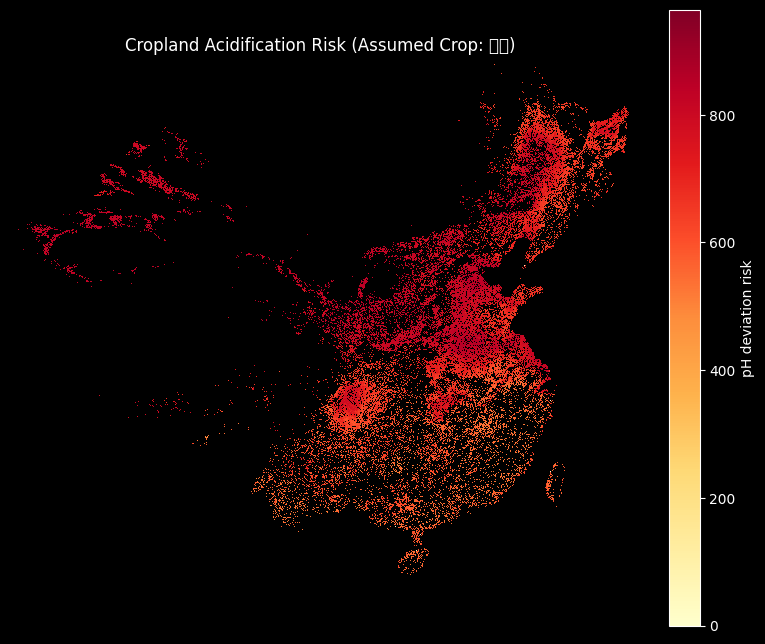

In [1]:
import sys
sys.path.append(r'C:\projects\soil_acid_risk\src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from preprocessing import load_raster
from risk_model import calc_acid_risk

# 1. 加载数据
lu_path = r'C:\projects\soil_acid_risk\data\landuse_2023.tif'
ph_path = r'C:\projects\soil_acid_risk\data\pH_aligned.tif'
crop_path = r'C:\projects\soil_acid_risk\data\crop_ph.csv'

lu_data, lu_transform, _ = load_raster(lu_path)
ph_data, _, _ = load_raster(ph_path)
crop_df = pd.read_csv(crop_path)

# 2. 计算风险
risk_array, stats = calc_acid_risk(lu_data, ph_data, crop_df, assumed_crop="水稻")

print("\n========== 酸化风险统计 ==========")
for k, v in stats.items():
    print(f"{k}: {v}")

# 3. 画热力图（只显示有风险的地方）
plt.figure(figsize=(10, 8))
# 把非耕地区域设为NaN，这样透明显示
risk_show = np.where(~np.isnan(risk_array), risk_array, np.nan)
plt.imshow(risk_show, cmap='YlOrRd', interpolation='nearest')
plt.colorbar(label='pH deviation risk')
plt.title('Cropland Acidification Risk (Assumed Crop: 水稻)')
plt.axis('off')
plt.show()